In [7]:
import json
import anndata as ad
import os
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
## MMC (ids and features)
datasetdic = {'minnie':{}, 'patchseq':{}}
featfiles = ['exc_{}_harmonized.h5ad'.format(key) for key in datasetdic.keys()]

for k, key in enumerate(datasetdic.keys()):
    curpath = os.path.join('/scratch/h5ad_outputs', featfiles[k])
    adata = ad.read_h5ad(curpath)

    df = pd.DataFrame(
        adata.X,
        columns=adata.var_names
    )
    datasetdic[key]['feats'] = df
    
    datasetdic[key]['id'] = adata.obs

In [39]:
datasetdic['patchseq']['id']

,cluster
0,L5 IT-2
1,L5 ET-2
2,L4 IT
3,L5 ET-3
4,L4/L5 IT
...,...
379,L6b
380,L6b
381,L6b
382,L6b


In [25]:
## MMC results
with open('/data/MMC-exc_minnie-from-exc_patchseq-v1/exc_mapping.json', 'rb') as src:
    mapping = json.load(src)

In [29]:
minnie_mapping_assignment = np.zeros(len(mapping['results']))
for i in range(len(minnie_mapping_assignment)):
    minnie_mapping_assignment[i] = mapping['results'][i]['cluster']['assignment']

NameError: name 'np' is not defined

In [30]:
mapping['results'][0]

{'cluster': {'assignment': 'L6 IT-3',
  'bootstrapping_probability': 0.5,
  'aggregate_probability': 0.5,
  'avg_correlation': 0.8007693105307575,
  'runner_up_assignment': ['L6b', 'L5/L6 IT Car3'],
  'runner_up_correlation': [0.7117746375196076, 0.909296897228225],
  'runner_up_probability': [0.25, 0.25],
  'directly_assigned': True},
 'cell_id': '23141'}

In [31]:
df = pd.DataFrame([
    {**item['cluster'], 'cell_id': item['cell_id']} 
    for item in mapping['results']
])

In [32]:
df.head()

,assignment,bootstrapping_probability,aggregate_probability,avg_correlation,runner_up_assignment,runner_up_correlation,runner_up_probability,directly_assigned,cell_id
0,L6 IT-3,0.500000,0.500000,0.800769,"[L6b, L5/L6 IT Car3]","[0.7117746375196076, 0.909296897228225]","[0.25, 0.25]",True,23141
1,L6 IT-3,0.607143,0.607143,0.652760,"[L2/3 IT, L5/L6 IT Car3, L6b]","[0.6310112774026223, 0.821025852962415, 0.2240...","[0.21428571428571427, 0.14285714285714285, 0.0...",True,23332
2,L6 IT-3,0.678571,0.678571,0.769960,"[L2/3 IT, L5/L6 IT Car3]","[0.4448343144686556, 0.8885016050431686]","[0.17857142857142858, 0.14285714285714285]",True,23373
3,L6 IT-3,0.607143,0.607143,0.540798,"[L5/L6 IT Car3, L6b, L2/3 IT]","[0.6761488961602117, 0.22903231162901505, 0.19...","[0.17857142857142858, 0.10714285714285714, 0.1...",True,23382
4,L6 IT-3,0.500000,0.500000,0.791378,"[L5/L6 IT Car3, L6b]","[0.9186547297926644, 0.485603859019521]","[0.2857142857142857, 0.21428571428571427]",True,23385


## first plot

/tmp/ipykernel_15905/3431935912.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


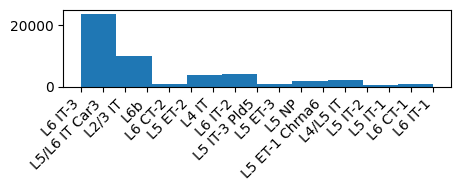

In [34]:
fig, ax = plt.subplots(figsize=[5,1])

ax.hist(df.assignment)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

## project in umap space with new labels and see if overlap

In [72]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.patches as mpatches


In [78]:
scaler = StandardScaler()
X_ps = scaler.fit_transform(datasetdic['patchseq']['feats'])
X_mn = scaler.transform(datasetdic['minnie']['feats'])

reducer = umap.UMAP(n_components=2, random_state=42, init='random')
ps_emb = reducer.fit_transform(X_ps)
mn_emb = reducer.transform(X_mn)

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [79]:
ps_labels = np.asarray(datasetdic['patchseq']['id']['cluster'].values.tolist())
mn_predicted = df.assignment.values

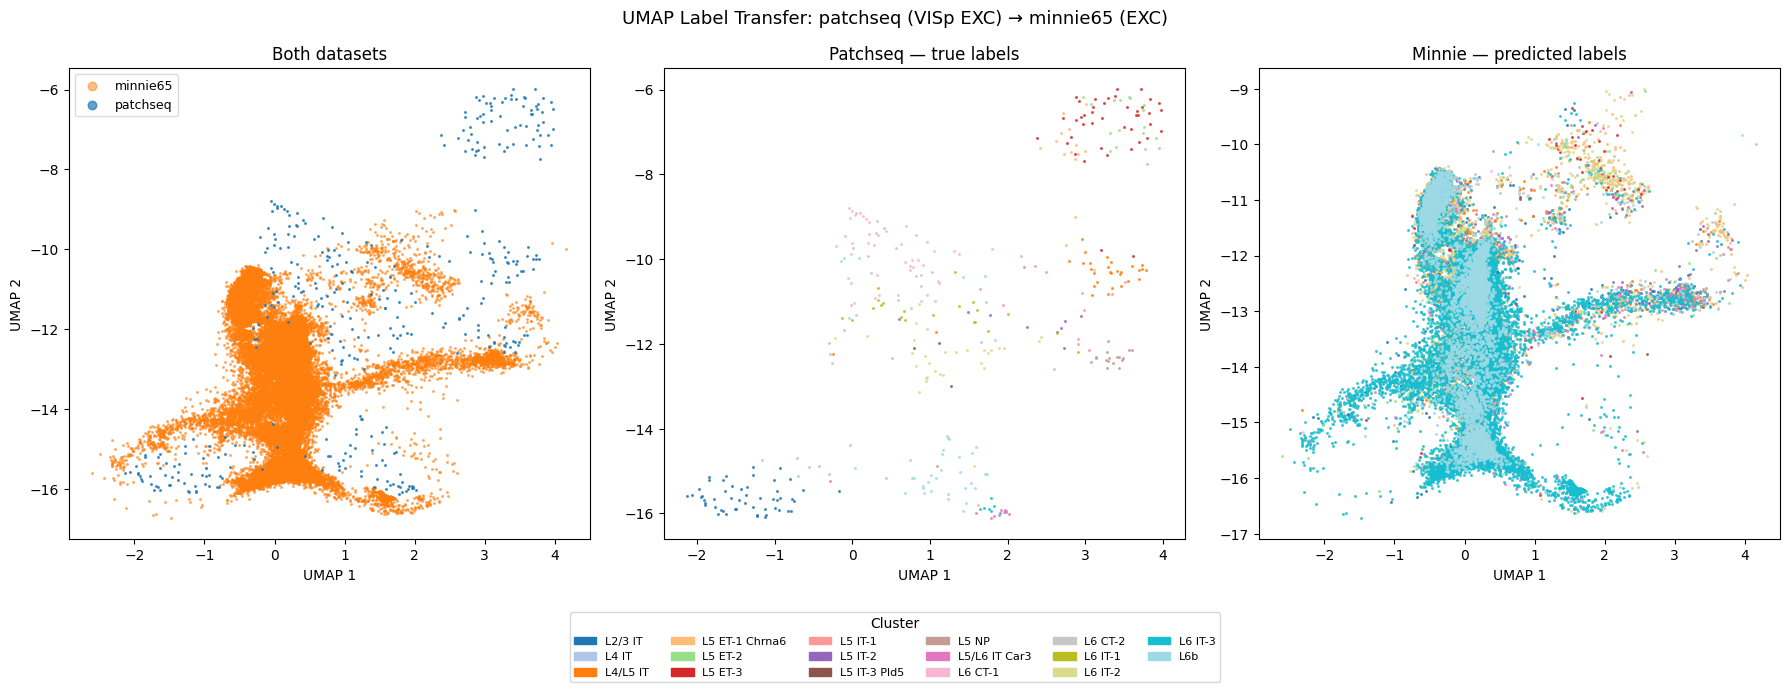

In [80]:
# ── Shared cluster colour map (tab20) ───────────────────────────────────────
all_cluster_labels = sorted(set(ps_labels) | set(mn_predicted))
cmap20 = plt.get_cmap('tab20')
cluster_colors = {
    lbl: cmap20(i / max(len(all_cluster_labels) - 1, 1))
    for i, lbl in enumerate(all_cluster_labels)
}

# Dataset-identity colours for the left panel
DS_COLORS = {'patchseq': '#1f77b4', 'minnie65': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Left: both datasets, coloured by dataset identity ────────────────────────
ax = axes[0]
ax.scatter(mn_emb[:, 0], mn_emb[:, 1],
           c=DS_COLORS['minnie65'], s=1.5, alpha=0.5, rasterized=True, label='minnie65')
ax.scatter(ps_emb[:, 0], ps_emb[:, 1],
           c=DS_COLORS['patchseq'], s=1.5, alpha=0.7, rasterized=True, label='patchseq')
ax.set_title('Both datasets')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(markerscale=5, framealpha=0.7, fontsize=9)

# ── Middle: patchseq, coloured by true cluster label ─────────────────────────
ax = axes[1]
for lbl in all_cluster_labels:
    mask = ps_labels == lbl
    if mask.any():
        ax.scatter(ps_emb[mask, 0], ps_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=0.7, rasterized=True)
ax.set_title('Patchseq — true labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Right: minnie, coloured by predicted cluster label ───────────────────────
ax = axes[2]
for lbl in all_cluster_labels:
    mask = mn_predicted == lbl
    if mask.any():
        ax.scatter(mn_emb[mask, 0], mn_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=0.7, rasterized=True)
ax.set_title('Minnie — predicted labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Shared cluster legend (below middle + right panels) ──────────────────────
handles = [mpatches.Patch(color=cluster_colors[lbl], label=lbl) for lbl in all_cluster_labels]
fig.legend(
    handles=handles, title='Cluster',
    loc='lower center', ncol=min(len(all_cluster_labels), 6),
    bbox_to_anchor=(0.5, -0.15), framealpha=0.8, fontsize=8
)

plt.suptitle('UMAP Label Transfer: patchseq (VISp EXC) → minnie65 (EXC)', fontsize=13)
plt.tight_layout()
plt.show()